In [18]:
import itertools
import re
from collections import defaultdict
from enum import Enum
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np

In [19]:
font_path = Path.cwd().parent / "fonts"
cmu_font_file = font_path / "cmunrm.otf"
font_manager.fontManager.addfont(cmu_font_file)

plt.rcParams["font.family"] = "CMU Serif"
plt.rcParams["mathtext.fontset"] = "cm"

mpl.rcParams['grid.linewidth'] = 0.5

mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['axes.edgecolor'] = 'lightgray'

mpl.rcParams["legend.frameon"] = True
mpl.rcParams["legend.facecolor"] = "white"
mpl.rcParams["legend.edgecolor"] = "gray"
mpl.rcParams["legend.framealpha"] = 1.0
mpl.rcParams["legend.fontsize"] = 10
mpl.rcParams['legend.markerscale'] = 0.8

In [20]:
LOG_DIR = Path("logs")

class Dataset(Enum):
    DL19 = "dl19"
    DL20 = "dl20"
    NEWS = "news"
    SIGNAL = "signal"
    TREC_COVID = "trec-covid"

RETRIEVE_K = (1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100)

class NoisePassages(Enum):
    NONE = "none"
    JUNK = "junk"
    RANDOM = "random"
    WORST1000 = "worst1000"

In [21]:
def create_log_path(
    log_dir: str | Path,
    dataset: Dataset | str,
    noise: NoisePassages | str,
    retrieve_k: int,
) -> Path:
    log_dir = Path(log_dir)

    if isinstance(dataset, str):
        dataset = Dataset(dataset)
    if isinstance(noise, str):
        noise = NoisePassages(noise)

    filename = Path(dataset.value, noise.value, f"k{retrieve_k}.log")
    return log_dir / filename

In [22]:
class AnchorRobustnessLog:
    def __init__(self, text: str):
        self.text = text

        ranking_metrics = self._metrics()
        self.original_metrics = ranking_metrics[0]
        self.noise_metrics = ranking_metrics[1] 

    @classmethod
    def from_file(cls, path: str | Path) -> "AnchorRobustnessLog":
        path = Path(path)
        if not path.exists():
            raise FileNotFoundError(f"File does not exist: `{path}`")
        text = path.read_text(encoding="utf-8")
        return cls(text)

    @classmethod
    def from_run(
        cls,
        log_dir: str | Path,
        dataset: Dataset | str,
        noise: NoisePassages | str,
        retrieve_k: int,
    ) -> "AnchorRobustnessLog":
        log_path = create_log_path(log_dir, dataset, noise, retrieve_k)
        return cls.from_file(log_path)
    
    def _metrics(self):
        performance_pattern = re.compile(r"(?:-+\sPERFORMANCE\s-+)(.*)", re.DOTALL)
        match = performance_pattern.search(self.text)
        performance = match.group(1).strip()

        ranking_pattern = re.compile(r"^(.*?)\n=+\n(.*?)\n=+", re.DOTALL + re.MULTILINE)
        matches = ranking_pattern.findall(performance)

        assert len(matches) == 2

        original_ranking = matches[0]
        noise_ranking = matches[1]

        def metrics_from_result_block(block):
            lines = block[1].splitlines()
            assert lines[0] == "Evaluation results :"

            metrics_string = lines[2:-2]
            metrics = defaultdict(dict)
            for metric_string in metrics_string:
                metric_at_ks, value_at_ks = metric_string.split(":")
                metric, ks = metric_at_ks.split("@")
                ks = list(map(int, ks.split("/")))
                values_at_ks = list(map(float, value_at_ks.split(", ")))
                for k, value in zip(ks, values_at_ks):
                    metrics[metric][k] = value
            return metrics

        original_ranking_metrics = metrics_from_result_block(original_ranking)
        noise_ranking_metrics = metrics_from_result_block(noise_ranking)
        return original_ranking_metrics, noise_ranking_metrics

        

In [23]:
log = AnchorRobustnessLog.from_run(
    LOG_DIR, Dataset.DL19, NoisePassages.JUNK, retrieve_k=10
)
log.original_metrics

defaultdict(dict,
            {'Accuarcy': {1: 0.97674, 2: 0.97674, 3: 1.0, 5: 1.0, 10: 1.0},
             'NDCG': {1: 0.83333,
              2: 0.79205,
              3: 0.7889,
              5: 0.77284,
              10: 0.74302},
             'MRR': {1: 0.97674, 2: 0.97674, 3: 0.9845, 5: 0.9845, 10: 0.9845},
             'Recall': {1: 0.02555,
              2: 0.04883,
              3: 0.07264,
              5: 0.11031,
              10: 0.17555},
             'Precision': {1: 0.97674,
              2: 0.94186,
              3: 0.94574,
              5: 0.90698,
              10: 0.83023},
             'MAP': {1: 0.02555,
              2: 0.04883,
              3: 0.07236,
              5: 0.10884,
              10: 0.16853}})

In [24]:
FIG_DPI = 100
# FIG_DPI = 300

def plot_retrieve_k_and_noise(dataset, metric: str = "NDCG", metric_k: int = 10):
    marker_cycle = itertools.cycle(["o", "s", "^", "D", "v", "p", "*", "X"])
    plt.figure(figsize=(6, 4), dpi=FIG_DPI)

    for noise in NoisePassages:
        ndcg_values_original = []
        ndcg_values_noise = []
        retrieve_ks = np.array(RETRIEVE_K)
        retrieve_ks = retrieve_ks[retrieve_ks >= metric_k]

        for k in retrieve_ks:
            try:
                log = AnchorRobustnessLog.from_run(
                    LOG_DIR, dataset, noise, retrieve_k=k
                )
            except FileNotFoundError:
                continue

            ndcg_original = log.original_metrics[metric][metric_k]
            ndcg_values_original.append(ndcg_original)

            ndcg_noise = log.noise_metrics[metric][metric_k]
            ndcg_values_noise.append(ndcg_noise)

        if not ndcg_values_noise:
            continue

        assert len(np.unique(ndcg_values_original, return_counts=True)[1]) == 1

        plt.plot(
            retrieve_ks,
            ndcg_values_noise,
            marker=next(marker_cycle),
            label=f"Noise: {noise.value}",
        )

    if ndcg_values_original:
        plt.axhline(
            ndcg_values_original[0],
            linestyle="dotted",
            color="gray",
            label="original",
        )

    plt.xlabel("retrieve $k$")
    plt.xticks(retrieve_ks)
    plt.ylabel(f"{metric}@{metric_k}")
    plt.ylim(0, 1.0)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

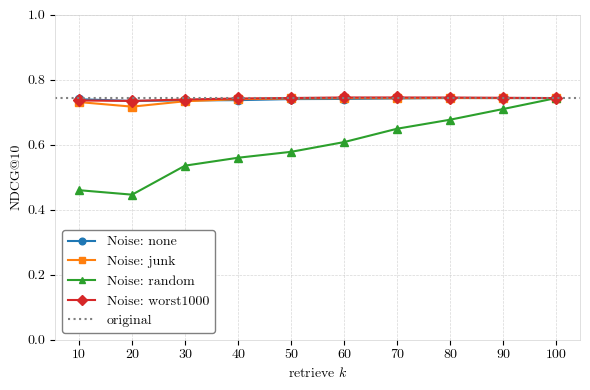

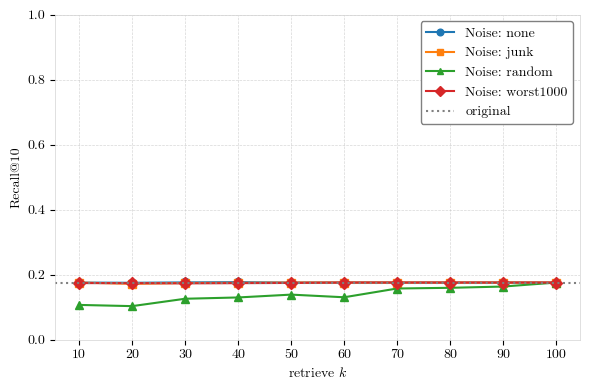

In [31]:
plot_retrieve_k_and_noise(Dataset.DL19, "NDCG", 10)
plot_retrieve_k_and_noise(Dataset.DL19, "Recall", 10)

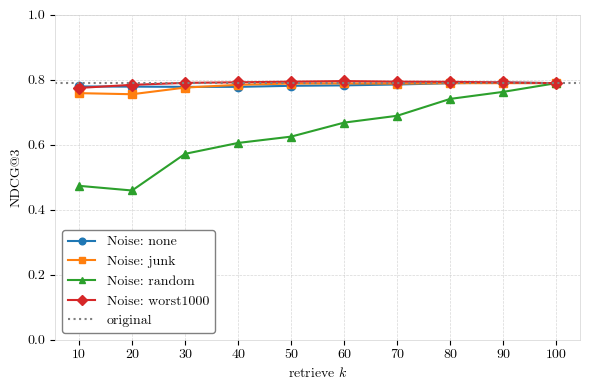

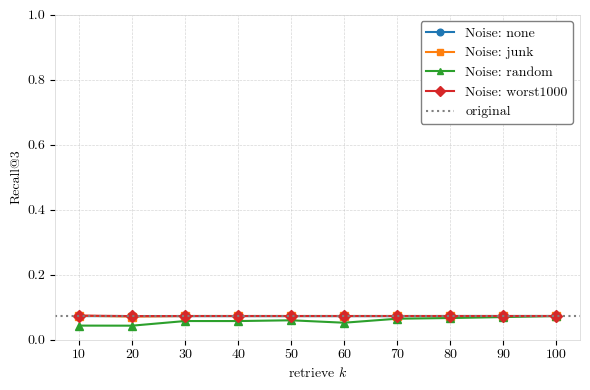

In [42]:
plot_retrieve_k_and_noise(Dataset.DL19, "NDCG", 3)
plot_retrieve_k_and_noise(Dataset.DL19, "Recall", 3)

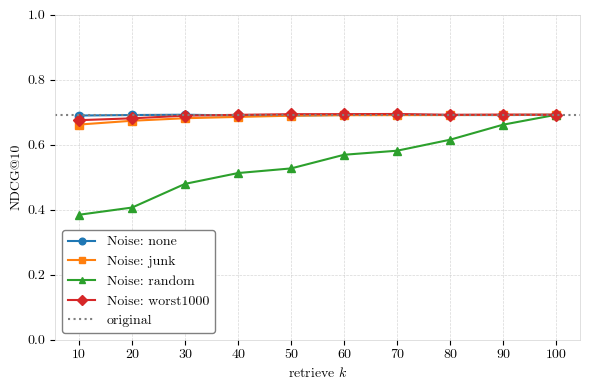

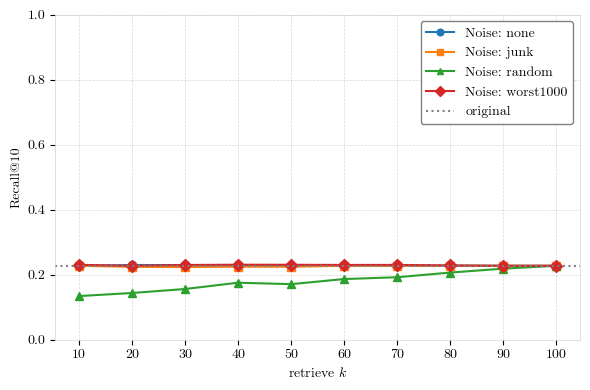

In [26]:
plot_retrieve_k_and_noise(Dataset.DL20, "NDCG", 10)
plot_retrieve_k_and_noise(Dataset.DL20, "Recall", 10)

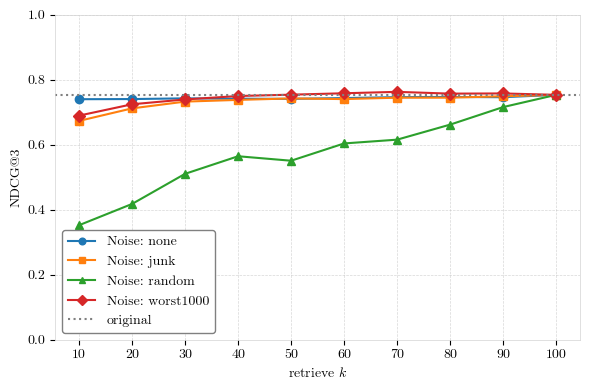

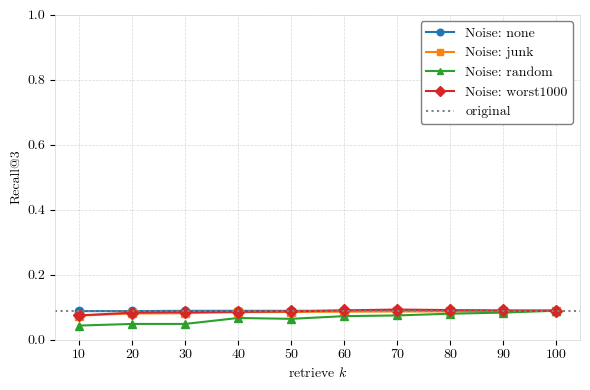

In [43]:
plot_retrieve_k_and_noise(Dataset.DL20, "NDCG", 3)
plot_retrieve_k_and_noise(Dataset.DL20, "Recall", 3)

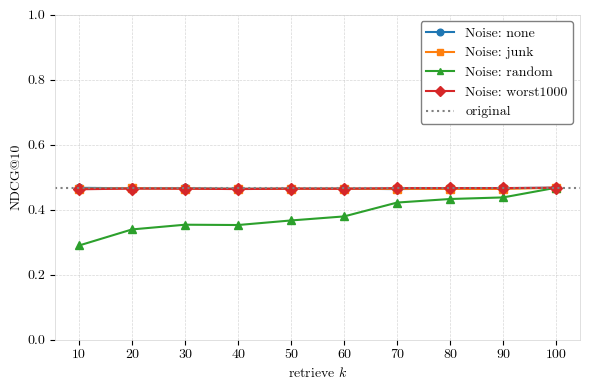

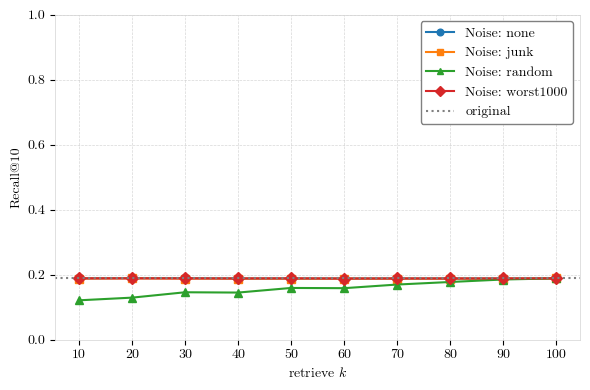

In [27]:
plot_retrieve_k_and_noise(Dataset.NEWS, "NDCG", 10)
plot_retrieve_k_and_noise(Dataset.NEWS, "Recall", 10)

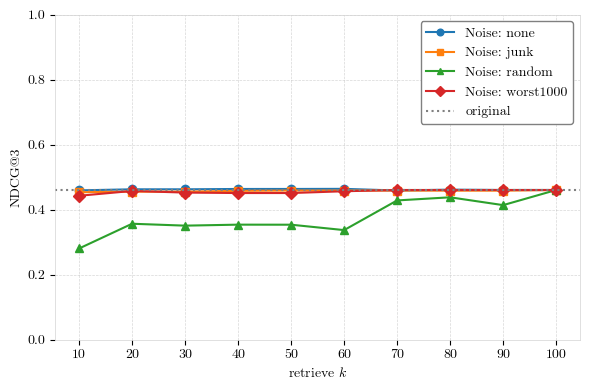

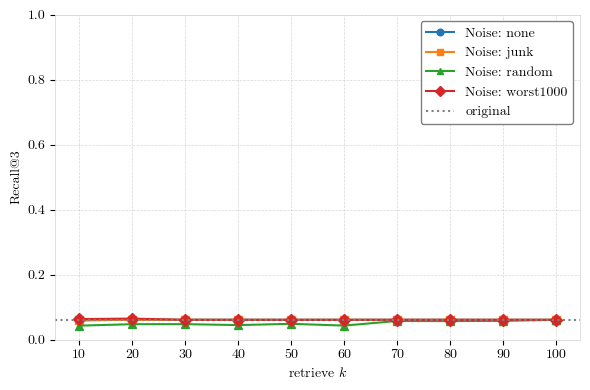

In [44]:
plot_retrieve_k_and_noise(Dataset.NEWS, "NDCG", 3)
plot_retrieve_k_and_noise(Dataset.NEWS, "Recall", 3)

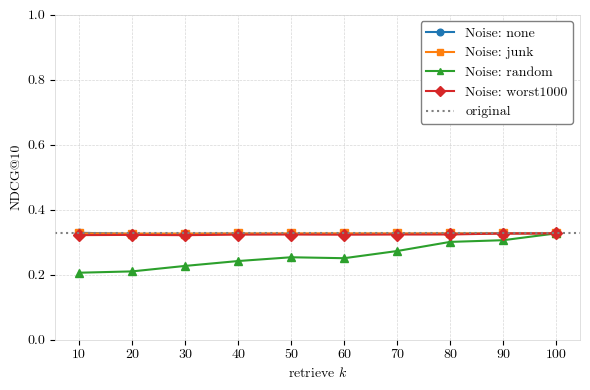

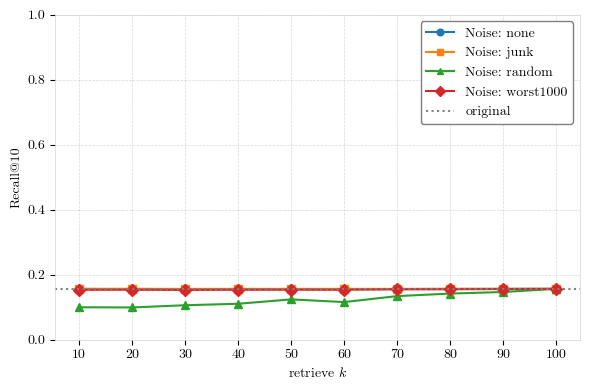

In [28]:
plot_retrieve_k_and_noise(Dataset.SIGNAL, "NDCG", 10)
plot_retrieve_k_and_noise(Dataset.SIGNAL, "Recall", 10)

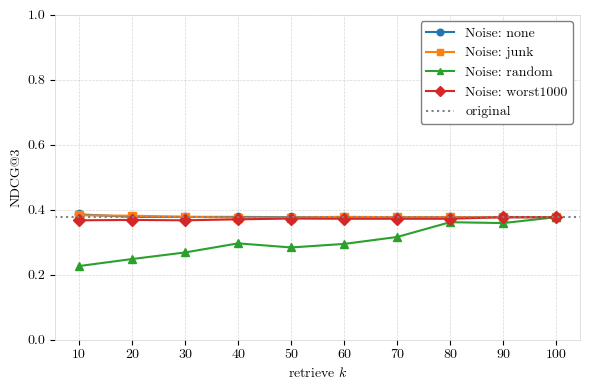

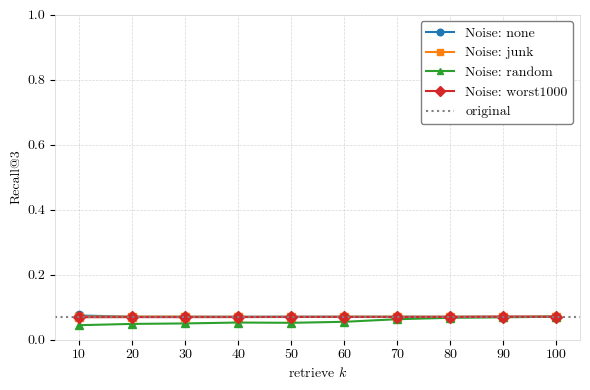

In [45]:
plot_retrieve_k_and_noise(Dataset.SIGNAL, "NDCG", 3)
plot_retrieve_k_and_noise(Dataset.SIGNAL, "Recall", 3)

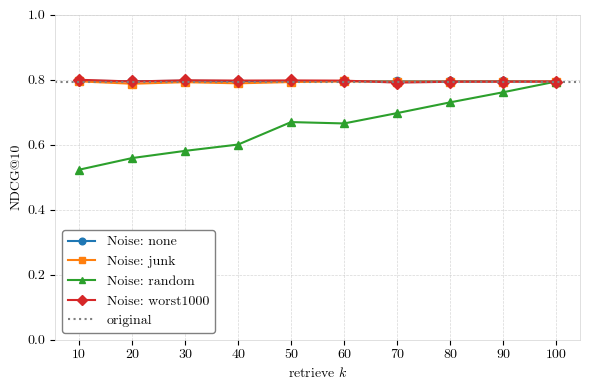

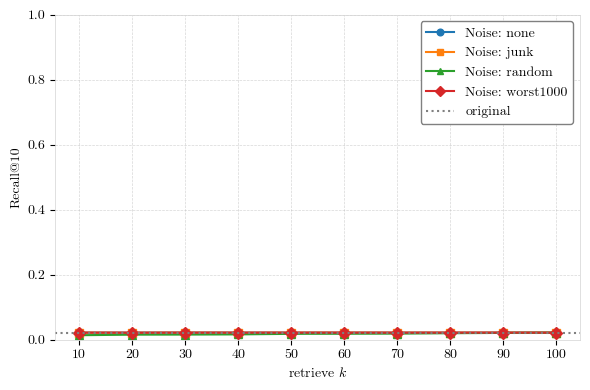

In [29]:
plot_retrieve_k_and_noise(Dataset.TREC_COVID, "NDCG", 10)
plot_retrieve_k_and_noise(Dataset.TREC_COVID, "Recall", 10)

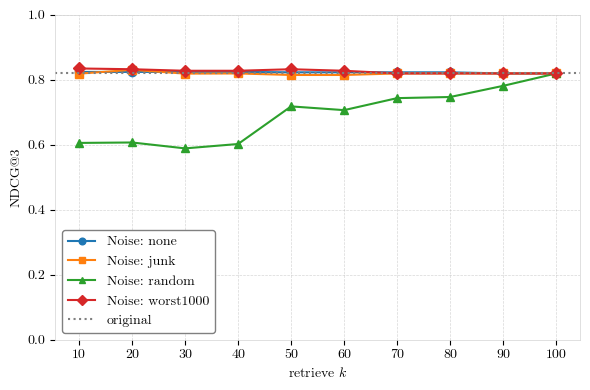

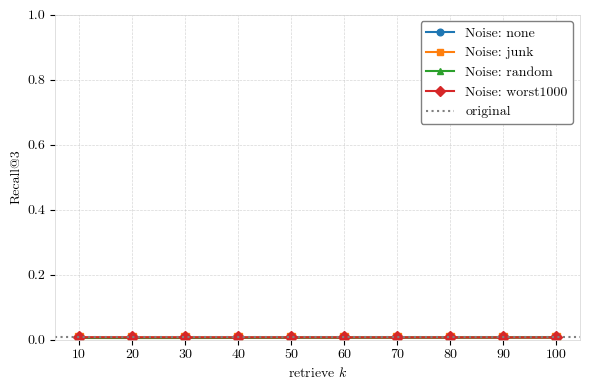

In [55]:
plot_retrieve_k_and_noise(Dataset.TREC_COVID, "NDCG", 3)
plot_retrieve_k_and_noise(Dataset.TREC_COVID, "Recall", 3)